# 教師あり学習<br>　　— 回帰 (教師あり学習)

## データセットの読み込み
- カリフォルニア州の各地域ごとの住宅価格のデータセット  
  [https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html)

In [19]:
# カリフォルニア州の各地域ごとの住宅価格のデータセット
# https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()    # housing : Bunch ≒ dict
# housing.data          = housing['data']           : ndarray   : 説明変数（独立変数）
# housing.feature_names = housing['feature_names']  : list      : 変数名のリスト
# housing.target        = housing['target']         : ndarray   : 目的変数（従属変数）
# housing.DESCR         = housing['DESCR']          : string    : データセットの概要

# print(housing.DESCR)
print("読み込み終了")

読み込み終了


説明変数：

    -  MedInc     世帯所得の中央値
    -  HouseAge   築年数の中央値
    -  AveRooms   部屋数の平均値
    -  AveBedrms  寝室数の平均値
    -  Population ブロックの人口
    -  AveOccup   世帯人数の平均値
    -  Latitude   ブロックの緯度
    -  Longitude  ブロックの経度

目的変数は住宅価格の中央値 (`MedHouseVal`，単位は十万ドル ($100,000)) である．  
この目的変数を，説明変数から推定するように学習させる．

In [20]:
import pandas as pd

#　説明変数を DataFrame にして x に代入
x = pd.DataFrame(housing.data, columns=housing.feature_names)

#　目的変数を Series にして y に代入
y = pd.Series(housing.target, name='MedHouseVal')

# x,y を結合
df = pd.concat([x, y], axis=1)
display(df)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## データセットの概要

In [21]:
# 各変数の基本統計量の確認
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


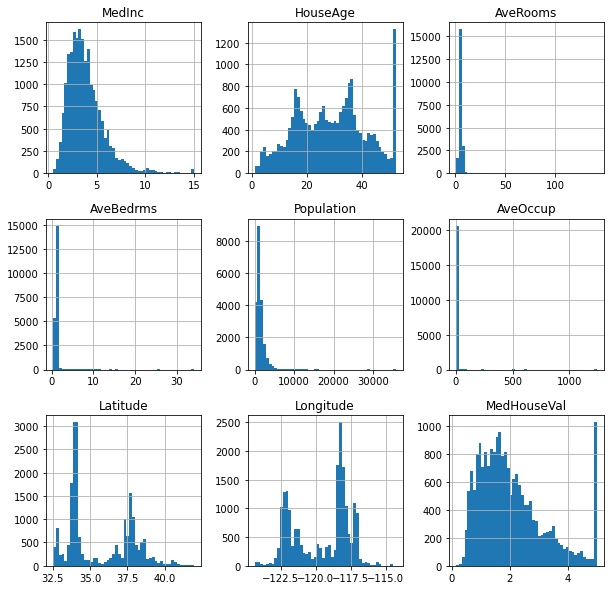

In [22]:
# 各変数のヒストグラム
import matplotlib.pyplot as plt

# binsで棒の数を多くして，figsize でグラフの大きさを大きくしている
df.hist(bins=50, figsize=(10, 10))
plt.show()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


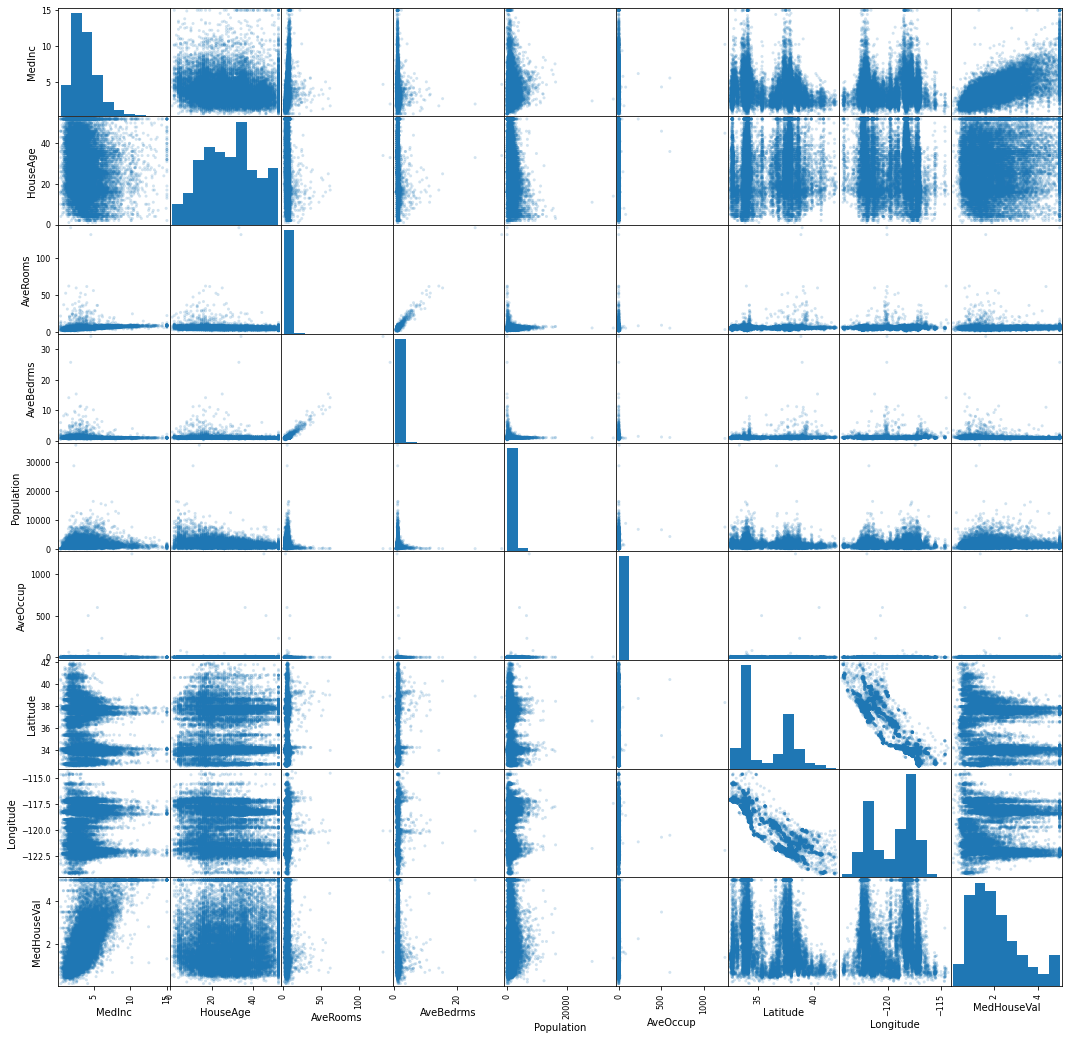

In [23]:
# 相関係数と散布図行列

# 相関係数表の表示 — 相関係数が1に近いほど強い正の相関，-1に近いほど強い負の相関，0に近いほど無相関
display(df.corr())

# 散布図行列の表示
from pandas.plotting import scatter_matrix
# figsize でグラフを大きくし，alpha でドットの透明度を上げている
sm = scatter_matrix(df, figsize=(18, 18), alpha=0.2)

## 準備 — 学習データとテストデータの分割

<div style="margin-left:4em;">

| 変数      | 内容 |
|:--------- |:---- |
| `x_train` | 訓練データの説明変数 |
| `x_test`  | テストデータの説明変数 |
| `y_train` | 訓練データの目的変数 |
| `y_test`  | テストデータの目的変数 |
</div>

- 訓練データのサイズは全体の70%(0.7)，テストデータのサイズは全体の30%(0.3)


In [24]:
# 学習データとテストデータの分割
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, test_size=0.3, random_state=0)

print("分割終了")

分割終了


## 単回帰分析による学習
- `MedInc` だけを説明変数として単回帰分析をしてみる
  $$
  \mathrm{MedHouseVal} = A\cdot\mathrm{MedInc} + B\quad(A: 係数，B: 切片)
  $$
  というモデル

In [25]:
# 単回帰分析とその結果

# 説明変数を MedInc のみに限定
x_train1 = x_train[["MedInc"]]
x_test1 = x_test[["MedInc"]]

# LinearRegression (回帰分析) モデルを生成して訓練データを適用
from sklearn.linear_model import LinearRegression
sr_model = LinearRegression()
sr_model.fit(x_train1, y_train)

# 結果の表示
print("切片 = ", sr_model.intercept_)
display(pd.DataFrame({"変数名": x_train1.columns, "係数": sr_model.coef_}))

切片 =  0.43306075947778555


,変数名,係数
0,MedInc,0.422899


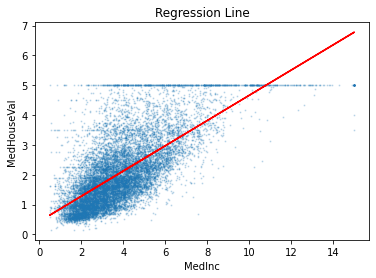

In [26]:
# グラフによる可視化
import matplotlib.pyplot as plt

plt.title("Regression Line")    # タイトル
plt.xlabel("MedInc")            # 横軸ラベル
plt.ylabel("MedHouseVal")       # 縦軸ラベル

plt.scatter(x_train1, y_train, s=1, alpha=0.2)    # 散布図(青)
plt.plot(x_train1['MedInc'], sr_model.predict(x_train1), color="red")  # 回帰直線(赤)

plt.show()  # 表示

In [27]:
# 決定係数の表示
# 0 ～ 1 で，1に近いほど良い成績
print("r^2 (訓練データ):   ", sr_model.score(x_train1, y_train))
print("r^2 (テストデータ): ", sr_model.score(x_test1, y_test))

r^2 (訓練データ):    0.4805817090322434
r^2 (テストデータ):  0.4564978967949699


In [28]:
# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
sr_pred_train = sr_model.predict(x_train1)
sr_pred_test = sr_model.predict(x_test1)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, sr_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, sr_pred_test)))

RMSE (訓練データ):    0.8314059950554484
RMSE (テストデータ):  0.851244384983201


## 重回帰分析による学習
- 説明変数すべてを使って重回帰分析をしてみる
  $$
  \mathrm{MedHouseVal}=A_0\cdot\mathrm{MedInc}+\cdots+A_7\cdot\mathrm{Longitude}+B
  \quad(A_0～A_7: 係数，B: 切片)
  $$
  というモデル

In [29]:
# 重回帰分析とその結果

# 説明変数 (x_train) はすべて使用

# LinearRegression (回帰分析) モデルを生成して訓練データを適用
from sklearn.linear_model import LinearRegression
mr_model = LinearRegression()
mr_model.fit(x_train, y_train)

# 結果の表示
print("切片 = ", mr_model.intercept_)
display(pd.DataFrame({"変数名": x_train.columns, "係数": mr_model.coef_}))

切片 =  -36.015755977895026


,変数名,係数
0,MedInc,0.446777
1,HouseAge,0.009185
2,AveRooms,-0.118104
3,AveBedrms,0.642251
4,Population,-0.000009
5,AveOccup,-0.004086
6,Latitude,-0.409045
7,Longitude,-0.423454


In [30]:
# 決定係数の表示
print("r^2 (訓練データ):   ", mr_model.score(x_train, y_train))
print("r^2 (テストデータ): ", mr_model.score(x_test, y_test))

r^2 (訓練データ):    0.6112583475310978
r^2 (テストデータ):  0.5926096960745021


In [31]:
# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
mr_pred_train = mr_model.predict(x_train)
mr_pred_test = mr_model.predict(x_test)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, mr_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, mr_pred_test)))

RMSE (訓練データ):    0.7192586118645157
RMSE (テストデータ):  0.7369855790507704


## FNNを用いた学習

In [32]:
# FNNの学習を行う
from sklearn.neural_network import MLPRegressor
# hidden_layer_sizes で隠れ層のユニット数を250に増加
mlp_model = MLPRegressor(random_state=0, hidden_layer_sizes=(250,))
mlp_model.fit(x_train, y_train)

# 決定係数の表示
print("r^2 (訓練データ):   ", mlp_model.score(x_train, y_train))
print("r^2 (テストデータ): ", mlp_model.score(x_test, y_test))

r^2 (訓練データ):    0.5810409225678301
r^2 (テストデータ):  0.5665452129371407


In [33]:
# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
mlp_pred_train = mlp_model.predict(x_train)
mlp_pred_test = mlp_model.predict(x_test)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, mlp_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, mlp_pred_test)))

RMSE (訓練データ):    0.746689999080435
RMSE (テストデータ):  0.7601959429838834


## ランダムフォレストを用いた学習

In [34]:
# ランダムフォレストの学習を行う
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=0)
rf_model.fit(x_train, y_train)

# 決定係数の表示
print("r^2 (訓練データ):   ", rf_model.score(x_train, y_train))
print("r^2 (テストデータ): ", rf_model.score(x_test, y_test))

r^2 (訓練データ):    0.9722903275469913
r^2 (テストデータ):  0.7943891687381662


In [35]:
# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
rf_pred_train = rf_model.predict(x_train)
rf_pred_test = rf_model.predict(x_test)

# 二乗平均平方根誤差(RMSE) — 二乗誤差の平均値の平方根
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, rf_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, rf_pred_test)))

RMSE (訓練データ):    0.19203050692371929
RMSE (テストデータ):  0.5235722738994336


## 結果のまとめ

In [36]:
print("単回帰分析:")
print("    訓練データ:")
print("        r^2:  ", sr_model.score(x_train1, y_train))
print("        RMSE: ", sqrt(mean_squared_error(y_train, sr_pred_train)))
print("    テストデータ:")
print("        r^2:  ", sr_model.score(x_test1, y_test))
print("        RMSE: ", sqrt(mean_squared_error(y_test, sr_pred_test)))

print("重回帰分析:")
print("    訓練データ:")
print("        r^2:  ", mr_model.score(x_train, y_train))
print("        RMSE: ", sqrt(mean_squared_error(y_train, mr_pred_train)))
print("    テストデータ:")
print("        r^2:  ", mr_model.score(x_test, y_test))
print("        RMSE: ", sqrt(mean_squared_error(y_test, mr_pred_test)))

print("FNN:")
print("    訓練データ:")
print("        r^2:  ", mlp_model.score(x_train, y_train))
print("        RMSE: ", sqrt(mean_squared_error(y_train, mlp_pred_train)))
print("    テストデータ:")
print("        r^2:  ", mlp_model.score(x_test, y_test))
print("        RMSE: ", sqrt(mean_squared_error(y_test, mlp_pred_test)))

print("ランダムフォレスト:")
print("    訓練データ:")
print("        r^2:  ", rf_model.score(x_train, y_train))
print("        RMSE: ", sqrt(mean_squared_error(y_train, rf_pred_train)))
print("    テストデータ:")
print("        r^2:  ", rf_model.score(x_test, y_test))
print("        RMSE: ", sqrt(mean_squared_error(y_test, rf_pred_test)))


単回帰分析:
    訓練データ:
        r^2:   0.4805817090322434
        RMSE:  0.8314059950554484
    テストデータ:
        r^2:   0.4564978967949699
        RMSE:  0.851244384983201
重回帰分析:
    訓練データ:
        r^2:   0.6112583475310978
        RMSE:  0.7192586118645157
    テストデータ:
        r^2:   0.5926096960745021
        RMSE:  0.7369855790507704
FNN:
    訓練データ:
        r^2:   0.5810409225678301
        RMSE:  0.746689999080435
    テストデータ:
        r^2:   0.5665452129371407
        RMSE:  0.7601959429838834
ランダムフォレスト:
    訓練データ:
        r^2:   0.9722903275469913
        RMSE:  0.19203050692371929
    テストデータ:
        r^2:   0.7943891687381662
        RMSE:  0.5235722738994336
